In [ ]:
import warnings
import pandas as pd
from PIL import Image
from os.path import join
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
import torchvision.transforms.functional as F
from transformers import ViTForImageClassification

In [2]:
warnings.filterwarnings("ignore")

### Params


In [3]:
DEVICE = "cpu"
WORK_DIR = "../.."
MODEL_PATH = "models/classification/vit_best.pth"
TRAIN_PATH = "data/open_image_dataset/train_remote.parquet"
MODEL_NAME = "google/vit-base-patch16-224"

In [4]:
df = pd.read_parquet(join(WORK_DIR, TRAIN_PATH))
num_classes = df["class"].max() + 1
id2name = dict(zip(df["class"], df["class_name"]))

In [5]:
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([423]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([423, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
model.load_state_dict(torch.load(join(WORK_DIR, MODEL_PATH), map_location=DEVICE))
model.to(DEVICE)
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [7]:
def resize(image: Image.Image, size: int = 224) -> Image.Image:
    return F.resize(image, (size, size))


def normalize_size(width, height, max_size=5):
    if max(width, height) <= max_size:
        return width, height
    if width >= height:
        norm_width = max_size
        norm_height = int(max_size * height / width)
    else:
        norm_height = max_size
        norm_width = int(max_size * width / height)
    return norm_width, norm_height


def show_image(img, width, height):
    fig, ax = plt.subplots(1, figsize=(width, height))
    fig.patch.set_visible(False)
    ax.imshow(img, aspect="equal")
    plt.axis("off")
    plt.show()


def predict(image_path, show=True):
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
        ]
    )
    image = Image.open(join(WORK_DIR, image_path))
    input_image = resize(image)
    input_image = transform(input_image.convert("RGB"))
    with torch.no_grad():
        image_predict = model(torch.stack([input_image])).logits
        label_score, label_id = torch.max(image_predict, 1)
        label_id, label_score = label_id.item(), label_score.item()

    if show:
        print(f"{id2name[label_id]}: {label_score:.3f}")

        orig_width, orig_height = image.size
        scaled_width, scaled_height = normalize_size(orig_width, orig_height)
        show_image(image, scaled_width, scaled_height)

    return label_id, label_score

Pastry: 7.750


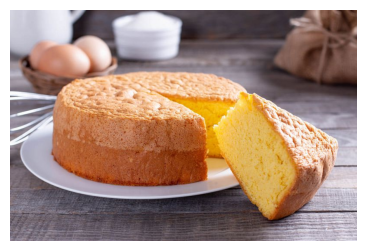

CPU times: user 947 ms, sys: 462 ms, total: 1.41 s
Wall time: 201 ms


In [8]:
%%time
img_path = "data/evaluate/detection/1.jpg"
label_id, label_score = predict(img_path)

Apple: 14.558


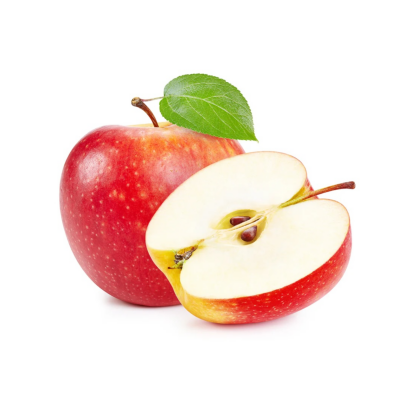

CPU times: user 1.14 s, sys: 453 ms, total: 1.59 s
Wall time: 180 ms


In [9]:
%%time
img_path = "data/evaluate/detection/2.jpg"
label_id, label_score = predict(img_path)

Cheese: 11.981


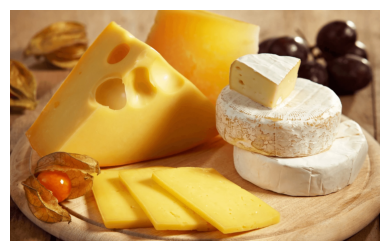

CPU times: user 1.21 s, sys: 604 ms, total: 1.81 s
Wall time: 212 ms


In [10]:
%%time
img_path = "data/evaluate/detection/3.jpg"
label_id, label_score = predict(img_path)

Pasta: 9.598


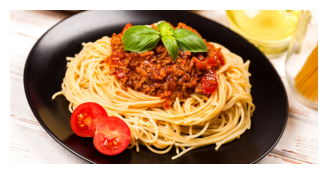

CPU times: user 1.41 s, sys: 646 ms, total: 2.06 s
Wall time: 310 ms


In [11]:
%%time
img_path = "data/evaluate/detection/4.jpg"
label_id, label_score = predict(img_path)

Croissant: 11.807


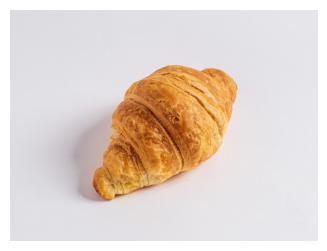

CPU times: user 1.08 s, sys: 506 ms, total: 1.59 s
Wall time: 198 ms


In [12]:
%%time
img_path = "data/evaluate/detection/5.jpg"
label_id, label_score = predict(img_path)